# Лабораторная работа № 1
## Сбор, визуализация и анализ данных по графу
**Тема:** прогнозирование дорожного движения методами машинного обучения.

Корпус: **361 проверенная публикация arXiv с 2020 года**. Исходные записи получены
через arXiv API 4–5 октября 2026 года; содержательный отбор завершён 5 октября.
Названия, авторы и аннотации сохранены без изменений.



### Подготовка и запуск

Ноутбук использует корпус из папки `data/`, сохранённые ответы BART и разметку поиска.
Откройте его с рабочей папкой, в которой находится `data/`, и выполните ячейки по порядку.
Графики и таблицы уже сохранены; повторный расчёт центральностей может занять несколько минут.

Проверено на **Python 3.14.5 (macOS)**. Для повторного запуска установите зависимости
в выбранное Python-окружение (интернет нужен только при установке):

```bash
python -m pip install \
  numpy==2.5.3 pandas==3.0.6 matplotlib==3.11.2 \
  networkx==3.7 scikit-learn==1.9.1 spacy==3.8.16 \
  torch==2.14.1 transformers==5.18.0 tqdm==4.70.1 \
  ipykernel==7.4.0
python -m pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl
```

После установки расчёт по приложенному корпусу выполняется локально.
Все 361 ответа BART уже есть в кэше; загрузка весов, Ollama и облачные API не требуются.
Новая установка зависимостей и запуск на других операционных системах отдельно не проверялись.

In [1]:
from pathlib import Path
from collections import Counter
from itertools import combinations
from functools import lru_cache
import json, re, hashlib, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from IPython.display import display, Markdown

ROOT = Path.cwd()
assert (ROOT / 'data/curated/publications_361.json').exists(), 'Запустите ноутбук из папки, в которой находится data/'
plt.rcParams.update({'figure.figsize': (10, 4), 'font.size': 11})
pd.set_option('display.max_colwidth', 130)

## 1. Данные с arXiv
Пункты 1–2 задания. Основной запрос по аннотациям (`traffic prediction`, `traffic forecasting`,
`traffic flow prediction`) вернул 692 записи; из них ранее отобраны 320.
Дополнительный запрос по скорости, времени поездки и заторам вернул 72 записи,
из них 61 новая относительно основной выгрузки. После проверки включена 41 статья.

Итого: **361 публикация**, дата первой подачи от 2020-01-01 до даты проверки 2026-10-05.



In [2]:
raw = json.loads((ROOT / 'data/raw/publications.json').read_text())
metadata = json.loads((ROOT / 'data/raw/collection_metadata.json').read_text())
supplement_raw = json.loads((ROOT / 'data/raw/supplement_320/publications.json').read_text())
supplement_metadata = json.loads((ROOT / 'data/raw/supplement_320/collection_metadata.json').read_text())
print('Основной запрос:', metadata['search_query'])
print('Дополнительный запрос:', supplement_metadata['search_query'])
print('Записей в выгрузках:', len(raw), '+', len(supplement_raw))
print('Уникальных кандидатов:', len({r['arxiv_id'] for r in raw + supplement_raw}))
display(pd.DataFrame(raw)[['arxiv_id', 'title', 'authors', 'published']].head(3))


Основной запрос: (abs:"traffic prediction" OR abs:"traffic forecasting" OR abs:"traffic flow prediction") AND submittedDate:[202001010000 TO 202612312359]
Дополнительный запрос: (ti:"traffic speed" OR ti:"travel time" OR ti:"traffic congestion") AND (all:prediction OR all:forecasting) AND (all:learning OR all:neural OR all:transformer) AND submittedDate:[202001010000 TO 202610052359]
Записей в выгрузках: 692 + 72
Уникальных кандидатов: 753


,arxiv_id,title,authors,published
0,2609.27637,Learning Local Heterogeneity and Cross-Region Context for Large-Scale Traffic Forecasting,"[Qi Feng, Zidong Wang, Bo Li, Xiaoguang Gao, Jiayu Zhang, Chenfeng Wang, Kaifang Wan]",2026-09-23T10:00:28Z
1,2609.25777,Disentangling Heterogeneous Traffic Dynamics for Multi-Step Traffic Forecasting via Adaptive Spectral Decomposition,"[Zijun Huang, Chenrui Fu, Wenhao Wang, Xiaochuan Gou, Chih-Chieh Hung, Guanyao Li]",2026-09-22T07:12:07Z
2,2609.21379,JEPA Guided Diffusion: Predictive Vision-Language Conditioning for Generative Traffic Forecasting,"[Trinh Tra Giang Nguyen, Thanh Nguyen Vo, Nguyen Hoai Thuong Bui, Ha Duc Bui]",2026-09-18T06:45:37Z


### Содержательный отбор дорожных исследований
Одних совпадений слов недостаточно: `traffic` может означать дорожный или компьютерный трафик.
Используем зафиксированный список по результатам чтения названий и полных аннотаций.
В отдельных пограничных случаях дополнительно проверены эксперименты в полном тексте.

Включаем ML-прогноз автомобильного потока, скорости, заторов и времени поездки,
обучаемый сценарный прогноз дорожной сети, специализированные обзоры и бенчмарки.
Общие методы принимаем только с подтверждённым дорожным прогнозным экспериментом.
Компьютерные сети, другой транспорт, пассажирский спрос и неясные случаи исключены
из основной выборки.

In [3]:
CORPUS_PATH = ROOT / 'data/curated/publications_361.json'
SELECTION_PATH = ROOT / 'data/curated/selection_361.json'
MANIFEST_PATH = ROOT / 'data/curated/corpus_361_manifest.json'
corpus_manifest = json.loads(MANIFEST_PATH.read_text())
selection = json.loads(SELECTION_PATH.read_text())
curated = json.loads(CORPUS_PATH.read_text())
assert hashlib.sha256(CORPUS_PATH.read_bytes()).hexdigest() == corpus_manifest['corpus_sha256']
assert hashlib.sha256(SELECTION_PATH.read_bytes()).hexdigest() == corpus_manifest['selection_sha256']
for origin in corpus_manifest['sources']:
    assert hashlib.sha256((ROOT / origin['records_file']).read_bytes()).hexdigest() == origin['sha256']


In [4]:
papers = pd.DataFrame(curated).reset_index(drop=True)
selected_ids = set(papers['arxiv_id'])
raw_by_id = {row['arxiv_id']: row for row in raw}
for row in supplement_raw:
    raw_by_id.setdefault(row['arxiv_id'], row)
assert len(papers) == 361 and papers['arxiv_id'].is_unique
assert selected_ids == set(corpus_manifest['selected_ids']) == {r['arxiv_id'] for r in selection}
assert all(r['decision'] == 'accept' and r['selected'] for r in selection)
assert all(row == raw_by_id[row['arxiv_id']] for row in curated)
assert papers['published'].str[:10].between('2020-01-01', corpus_manifest['review_date']).all()
assert all(row['title'] and row['authors'] and row['abstract'] for row in curated)
for field in ['title', 'abstract']:
    assert papers[field].str.lower().str.replace(r'\s+', ' ', regex=True).is_unique

print('В корпусе:', len(papers), 'уникальных статей')
display(pd.DataFrame(selection)[['arxiv_id', 'title', 'reason_ru']].head(5))


В корпусе: 361 уникальных статей


,arxiv_id,title,reason_ru
0,2609.36156,Traffic Congestion Awareness and On-Demand Distribution in Vehicular Delay-Tolerant Networks in California I-210 Freeway,Прогнозируются повторяемость и длительность дорожных заторов по PeMS с ML; сетевые сообщения — применение этого прогноза.
1,2609.27637,Learning Local Heterogeneity and Cross-Region Context for Large-Scale Traffic Forecasting,"LoReST прогнозирует дорожный поток, сочетая соседние датчики и регионы сети, и проверен на LargeST."
2,2609.25777,Disentangling Heterogeneous Traffic Dynamics for Multi-Step Traffic Forecasting via Adaptive Spectral Decomposition,ADNet прогнозирует дорожные состояния на датасете TraffiDent.
3,2609.20026,FedeRICo: Federated Region-Influenced Coupling for Traffic Flow Prediction,FedeRICo прогнозирует дорожный трафик по графам датчиков с передачей сигналов через границы разделённой дорожной сети.
4,2609.16573,AsyncCouple-Flow: Asynchronous Cross-Modal Coupling and Flow Matching for Spatio-Temporal Forecasting,Общая модель содержит явный эксперимент прогнозирования дорожного трафика PEMS-BAY.


В корпусе **361 публикация**. Названия, авторы, аннотации и даты проверены по сохранённым ответам arXiv API. Тематика — прогнозирование дорожного движения методами машинного обучения.

## 2. Разведочный анализ
Пункт 3 задания. Посмотрим, когда опубликованы статьи, насколько длинны аннотации
и сколько авторов у статей. 2026 год неполный; напрямую сравнивать его с полными годами нельзя.

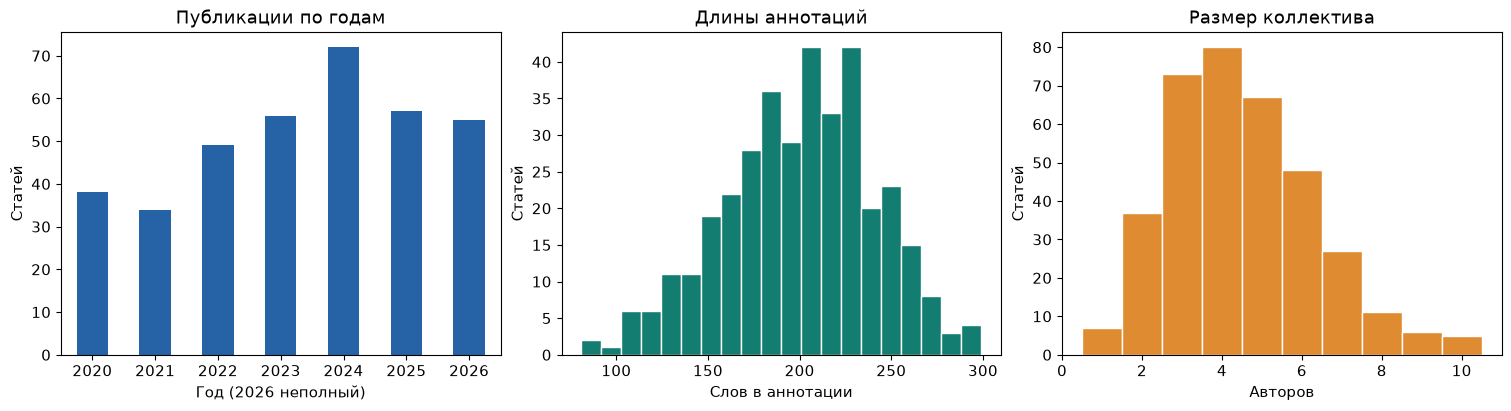

,abstract_words,author_count
count,361.0,361.0
mean,200.0,4.5
std,40.8,1.8
min,81.0,1.0
25%,175.0,3.0
50%,202.0,4.0
75%,227.0,6.0
max,299.0,10.0


In [5]:
papers['year'] = papers['published'].str[:4].astype(int)
papers['abstract_words'] = papers['abstract'].str.findall(r'[A-Za-z]+').str.len()
papers['author_count'] = papers['authors'].str.len()
fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout='constrained')
papers['year'].value_counts().sort_index().plot.bar(ax=axes[0], color='#2563a6', rot=0)
papers['abstract_words'].plot.hist(ax=axes[1], bins=20, color='#147d72', edgecolor='white')
papers['author_count'].plot.hist(ax=axes[2], bins=np.arange(1, papers['author_count'].max() + 2) - 0.5,
                                color='#df8b32', edgecolor='white')
for ax, title, label in zip(axes, ['Публикации по годам', 'Длины аннотаций', 'Размер коллектива'],
                           ['Год (2026 неполный)', 'Слов в аннотации', 'Авторов']):
    ax.set(title=title, xlabel=label, ylabel='Статей')
plt.show()
display(papers[['abstract_words', 'author_count']].describe().round(1))

### Закон Ципфа
Самое частое слово имеет ранг 1, следующее — 2 и так далее. Закон Ципфа описывает
приближённую зависимость $f(r) \propto 1/r$: в логарифмических координатах наклон близок к −1.
Здесь считаем слова **со стоп-словами, до лемматизации**.

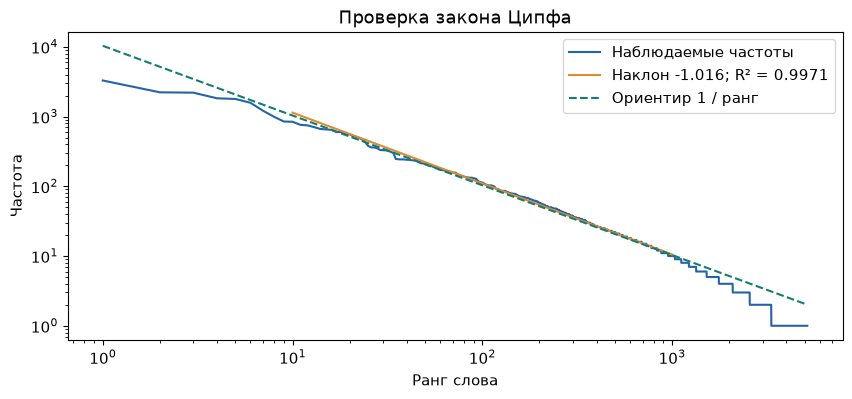

Словоупотреблений: 76334 Различных словоформ: 5164


In [6]:
texts = papers['title'] + '. ' + papers['abstract']
word_counts = Counter(re.findall(r'[a-z]+', ' '.join(texts).lower()))
frequency = np.array(sorted(word_counts.values(), reverse=True))
rank = np.arange(1, len(frequency) + 1)
fit = (rank >= 10) & (rank <= 1000)
slope, intercept = np.polyfit(np.log10(rank[fit]), np.log10(frequency[fit]), 1)
observed = np.log10(frequency[fit])
predicted = slope * np.log10(rank[fit]) + intercept
r2 = 1 - np.sum((observed - predicted)**2) / np.sum((observed - observed.mean())**2)
plt.loglog(rank, frequency, label='Наблюдаемые частоты', color='#2563a6')
plt.loglog(rank[fit], 10**predicted, label=f'Наклон {slope:.3f}; R² = {r2:.4f}', color='#df8b32')
plt.loglog(rank, frequency[49] * 50 / rank, '--', label='Ориентир 1 / ранг', color='#147d72')
plt.xlabel('Ранг слова'); plt.ylabel('Частота'); plt.title('Проверка закона Ципфа')
plt.legend(); plt.show()
print('Словоупотреблений:', sum(word_counts.values()), 'Различных словоформ:', len(word_counts))

Частоты, наклон и R² рассчитаны выше на текущих 361 статье.
Сходство с законом Ципфа оцениваем по форме log–log графика и наклону на рангах 10–1000;
оно не доказывает тематическую однородность или качество ключевых слов.


## 3. Ключевые слова: BART + TF-IDF
Используем модель [ilsilfverskiold/tech-keywords-extractor](https://huggingface.co/ilsilfverskiold/tech-keywords-extractor).
Она получает **название и аннотацию** и возвращает ключевые фразы.
TF-IDF дополнительно выделяет характерные для статьи униграммы, биграммы и триграммы.

### 3.1. Ответы модели
Версия модели и параметры зафиксированы. Для уже обработанных текстов используем кэш.

In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm.auto import tqdm

torch.set_num_threads(4)
MODEL_DIR = ROOT / '.cache/models/tech-keywords-extractor'
CACHE_PATH = ROOT / 'data/processed/bart_keyword_cache.json'
GENERATION = dict(max_new_tokens=128, do_sample=False, num_beams=4,
                  early_stopping=True, no_repeat_ngram_size=3)
MODEL_CONFIG = {
    'model': 'ilsilfverskiold/tech-keywords-extractor',
    'revision': '2f1ab22c4b291db80c5f0bc4ad57236240fb0560',
    'generation': GENERATION, 'input': 'title + . + abstract', 'schema': 1,
}
cache = json.loads(CACHE_PATH.read_text()) if CACHE_PATH.exists() else {}
text_by_id = dict(zip(papers['arxiv_id'], texts))


def cache_key(text):
    payload = json.dumps({'config': MODEL_CONFIG, 'text': text}, sort_keys=True)
    return hashlib.sha256(payload.encode()).hexdigest()


missing = [pid for pid, text in text_by_id.items() if cache_key(text) not in cache]
print('Готовых ответов:', len(papers) - len(missing), '| Нужно вычислить:', len(missing))

/Users/kolyantramplin/PycharmProjects/transport_traffic/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Готовых ответов: 361 | Нужно вычислить: 0


In [8]:
if missing:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
    device = 'mps' if torch.backends.mps.is_available() else 'cpu'
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_DIR, local_files_only=True).to(device).eval()
    for pid in tqdm(missing, desc='Ключевые фразы BART'):
        text = text_by_id[pid]
        inputs = tokenizer(text, return_tensors='pt').to(device)
        if inputs['input_ids'].shape[1] > model.config.max_position_embeddings:
            raise ValueError(f'{pid}: текст длиннее контекста модели')
        with torch.inference_mode():
            output = model.generate(**inputs, **GENERATION)
            if output.shape[1] >= 129:
                output = model.generate(**inputs, **{**GENERATION, 'max_new_tokens': 256})
                if output.shape[1] >= 257:
                    raise ValueError(f'{pid}: достигнут предел длины ответа')
        cache[cache_key(text)] = {
            'arxiv_id': pid, 'config': MODEL_CONFIG,
            'generated_text': tokenizer.decode(output[0], skip_special_tokens=True),
            'input_tokens': int(inputs['input_ids'].shape[1]),
        }
        temporary = CACHE_PATH.with_suffix('.tmp')
        temporary.write_text(json.dumps(cache, ensure_ascii=False, indent=2))
        temporary.replace(CACHE_PATH)
    del model
    if device == 'mps':
        torch.mps.empty_cache()

raw_keywords = {pid: cache[cache_key(text)]['generated_text'] for pid, text in text_by_id.items()}
print('Ключевые фразы получены для', len(raw_keywords), 'статей')

Ключевые фразы получены для 361 статей


### 3.2. Простая нормализация
Приводим текст к нижнему регистру, заменяем дефисы пробелами, убираем ссылки и пунктуацию,
лемматизируем существительные. Формы `learning` и `forecasting` сохраняем.
Ручных списков запрещённых тем и словарей методов нет. Английские стоп-слова исключаются при расчёте TF-IDF.
Фразы модели принимаем только при наличии в исходном тексте после той же нормализации.

In [9]:
import spacy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])


@lru_cache(maxsize=20000)
def normalize(text):
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'[-‐‑–—/]', ' ', text.lower())
    doc = nlp(text)
    return ' '.join(token.lemma_ if token.pos_ == 'NOUN' and not token.text.endswith('ing')
                    and token.text not in {'data', 'series'} else token.text
                    for token in doc if token.is_alpha)


normalized_texts = texts.map(normalize)
source_parts = {pid: [' ' + normalize(part) + ' ' for part in re.split(r'[.!?;:]', text)]
                for pid, text in text_by_id.items()}


def supported(term, pid):
    return bool(term) and any(' ' + term + ' ' in part for part in source_parts[pid])


model_tags = {pid: sorted({normalize(term) for term in re.split(r'[,;\n]+', response)
                          if supported(normalize(term), pid)})
              for pid, response in raw_keywords.items()}
# Общий словарь модели: одна и та же фраза становится тегом во всех текстах, где встречается.
model_vocabulary = sorted({term for terms in model_tags.values() for term in terms})
model_candidates = {pid: [term for term in model_vocabulary if supported(term, pid)]
                    for pid in text_by_id}


### 3.3. TF-IDF и итоговые теги
Из общего словаря BART находим фразы, реально встречающиеся в статье.
Берём до шести таких фраз с наибольшим TF-IDF и дополняем шестью терминами TF-IDF из названия и аннотации.
Для отбора тегов название учитываем трижды, аннотацию — один раз.
TF-IDF рассматривает 1–3 слова, встречающиеся хотя бы в двух статьях; при отборе умножаем вес
на корень из числа слов, чтобы поддержать словосочетания. Точные повторы убираем.
Среди добавленных TF-IDF-тегов не оставляем вложенные варианты одной фразы;
короткий вариант длинной фразы BART допустим, поскольку связывает разные статьи.
Каждый тег должен непрерывно встречаться в нормализованном исходном тексте.


In [10]:
stop_words = sorted({token for word in ENGLISH_STOP_WORDS for token in normalize(word).split()} - {''})
vectorizer = TfidfVectorizer(ngram_range=(1, 3), stop_words=stop_words,
                             min_df=2, max_df=0.85, sublinear_tf=True)
text_matrix = vectorizer.fit_transform(normalized_texts)
keyword_texts = (papers['title'] + '. ' + papers['title'] + '. ' + texts).map(normalize)
keyword_matrix = vectorizer.transform(keyword_texts)
features = vectorizer.get_feature_names_out()


tags, tfidf_tags = {}, {}
for i, pid in enumerate(papers['arxiv_id']):
    row = keyword_matrix.getrow(i)
    weights = {features[j]: float(value) for j, value in zip(row.indices, row.data)}
    def phrase_score(term):
        return weights.get(term, np.mean([weights.get(word, 0.0) for word in term.split()]))
    model_ranked = sorted(model_candidates[pid], key=lambda term: (-phrase_score(term), term))
    chosen = model_ranked[:6]
    ranked = sorted(weights, key=lambda term: (-weights[term] * np.sqrt(len(term.split())), term))
    tfidf_tags[pid] = []
    for term in ranked:
        # Не заполняем все места вложенными вариантами одной TF-IDF-фразы.
        if term in chosen or not supported(term, pid):
            continue
        if any(' ' + term + ' ' in ' ' + other + ' ' or ' ' + other + ' ' in ' ' + term + ' '
               for other in tfidf_tags[pid]):
            continue
        tfidf_tags[pid].append(term)
        if len(tfidf_tags[pid]) == 6:
            break
    tags[pid] = chosen + tfidf_tags[pid]

papers['keywords'] = papers['arxiv_id'].map(tags)
display(pd.DataFrame({'Название': papers['title'], 'BART': papers['arxiv_id'].map(model_tags),
                      'TF-IDF': papers['arxiv_id'].map(tfidf_tags), 'Итоговые теги': papers['keywords']}).head(6))
print('Терминов:', len({term for words in tags.values() for term in words}))
print('Тегов на статью в среднем:', round(papers['keywords'].str.len().mean(), 2))
print('Статей без тегов:', sum(not words for words in tags.values()))

,Название,BART,TF-IDF,Итоговые теги
0,Traffic Congestion Awareness and On-Demand Distribution in Vehicular Delay-Tolerant Networks in California I-210 Freeway,"[california i freeway, on demand distribution, pem, traffic congestion awareness, vehicular delay tolerant network]","[delay tolerant, freeway traffic, congestion event, free flow, vehicular, flow speed]","[vehicular delay tolerant network, congestion, california, traffic congestion, traffic congestion awareness, california i free..."
1,Learning Local Heterogeneity and Cross-Region Context for Large-Scale Traffic Forecasting,"[cross region context, large scale traffic forecasting, local heterogeneity, lorest, mae, mape, rmse]","[cross region, scale traffic forecasting, large scale traffic, heterogeneity, context, local]","[cross region context, local heterogeneity, large scale, spatial dependency, largest, traffic forecasting, cross region, scale..."
2,Disentangling Heterogeneous Traffic Dynamics for Multi-Step Traffic Forecasting via Adaptive Spectral Decomposition,"[adaptive decomposition network, adnet, alameda, multi step traffic forecasting, orange region, traffident]","[multi step traffic, step traffic forecasting, heterogeneous traffic, decomposition, disentangling, spectral]","[adaptive decomposition network, traffic dynamic, alameda, traffident, multi step traffic forecasting, spatiotemporal forecast..."
3,FedeRICo: Federated Region-Influenced Coupling for Traffic Flow Prediction,"[federated region influenced coupling, federico, traffic flow prediction]","[client, parameter aggregation, boundary, federated, coupling, residual]","[federated region influenced coupling, spatial dependency, spatial topology, traffic flow prediction, urban traffic forecastin..."
4,AsyncCouple-Flow: Asynchronous Cross-Modal Coupling and Flow Matching for Spatio-Temporal Forecasting,"[asynccouple flow, asynchronous cross modal coupling, flow matching, mat, mm stf, multi modal spatio temporal forecasting, pem...","[cross modal, modality, temporal forecasting, multi modal, asynchronous, coupling]","[asynchronous cross modal coupling, spatio temporal forecasting, flow matching, token sparsification, weather, multi modal spa..."
5,STHMoE: Hypergraph-Enhanced Heterogeneous Dependency Coordination for LLM-Based Urban Traffic Data Forecasting,"[deep learning, heterogeneous dependency coordination, hypergraph, large language model, llm, sthmoe, urban traffic data forec...","[urban traffic data, llm based, data forecasting, heterogeneous dependency, coordination, expert]","[hypergraph, llm, heterogeneous dependency coordination, spatio temporal hypergraph, traffic data, big data, urban traffic dat..."


Терминов: 2224
Тегов на статью в среднем: 12.0
Статей без тегов: 0


## 4. Граф ключевых слов
Вершины — итоговые теги. Ребро соединяет два тега одной статьи;
его вес — число статей, в которых они встречаются вместе.
Сообщества выделяем алгоритмом Louvain на полном графе, качество разбиения оцениваем модулярностью.

In [11]:
pair_counts = Counter(pair for terms in tags.values() for pair in combinations(sorted(set(terms)), 2))
G = nx.Graph()
G.add_nodes_from(sorted({term for terms in tags.values() for term in terms}))
G.add_weighted_edges_from((a, b, weight) for (a, b), weight in sorted(pair_counts.items()))
communities = sorted(nx.community.louvain_communities(G, weight='weight', seed=42),
                     key=lambda group: (-len(group), min(group)))
community_id = {term: i + 1 for i, group in enumerate(communities) for term in group}
modularity = nx.community.modularity(G, communities, weight='weight')
print(f'Терминов: {len(G)}; связей: {G.number_of_edges()}; сообществ: {len(communities)}; Q = {modularity:.3f}')

cluster_table = []
for i, group in enumerate(communities, 1):
    leaders = sorted(G.subgraph(group).degree(weight='weight'), key=lambda item: (-item[1], item[0]))[:6]
    cluster_table.append({'Кластер': i, 'Терминов': len(group),
                          'Ведущие термины': ', '.join(term for term, _ in leaders)})
display(pd.DataFrame(cluster_table).head(8))

Терминов: 2224; связей: 22180; сообществ: 19; Q = 0.493


,Кластер,Терминов,Ведущие термины
0,1,233,"traffic flow prediction, traffic flow, llm, large language model, privacy, federated learning"
1,2,190,"travel time, travel time prediction, time prediction, prediction, travel time estimation, time estimation"
2,3,178,"graph neural network, spatio temporal, graph neural, gnn, graph, neural network"
3,4,168,"convolutional network, graph convolutional network, attention, temporal graph convolutional, attention network, spatio tempora..."
4,5,155,"traffic forecasting, traffic prediction, long term traffic, term traffic forecasting, deep learning, short term traffic"
5,6,149,"road network, spatial temporal, traffic data, spatial dependency, urban traffic, hypergraph"
6,7,128,"traffic speed, traffic speed prediction, speed prediction, lstm, transportation network, hurricane"
7,8,122,"recurrent network, graph convolutional recurrent, convolutional recurrent network, graph convolution, convolution network, gcrn"


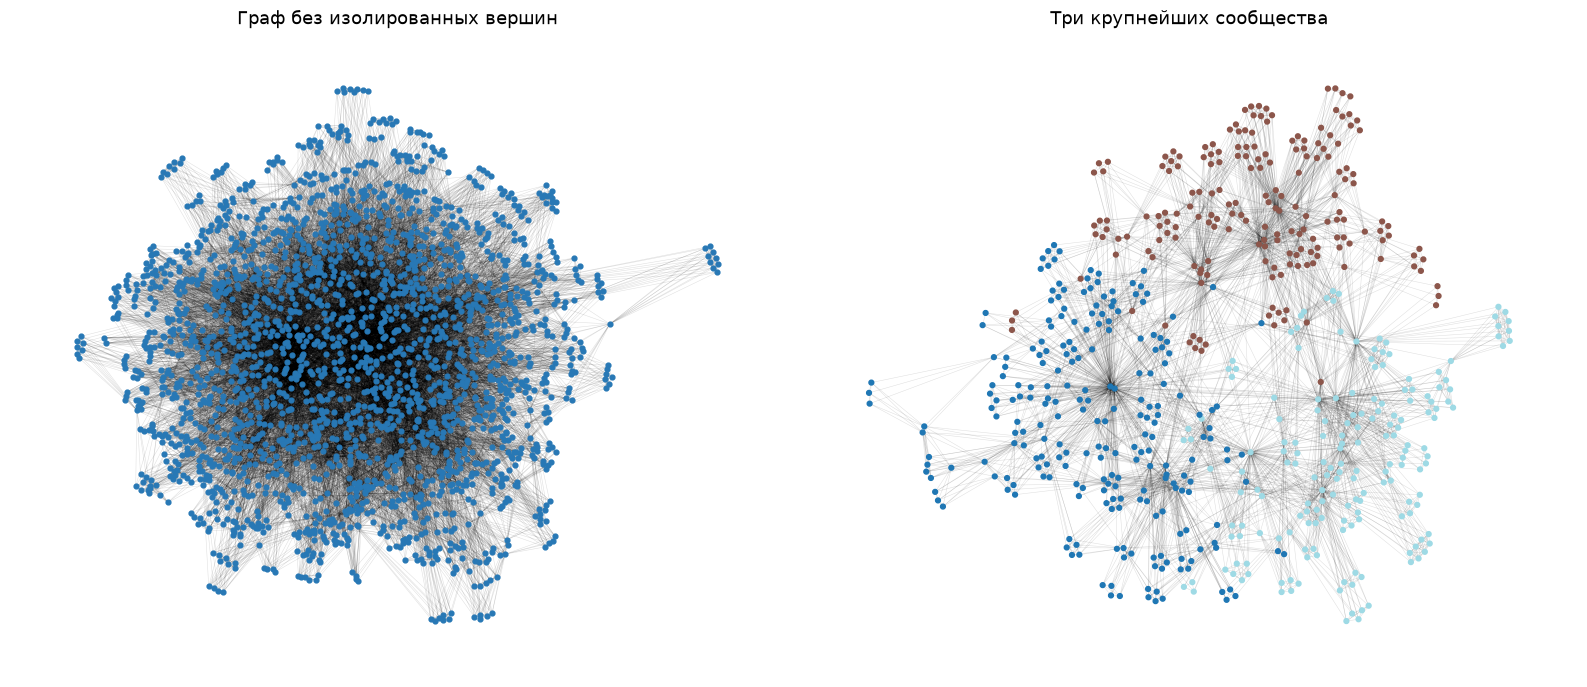

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, nodes, title in [(axes[0], set(G) - set(nx.isolates(G)), 'Граф без изолированных вершин'),
                         (axes[1], set().union(*communities[:3]), 'Три крупнейших сообщества')]:
    graph = G.subgraph(sorted(nodes))
    pos = nx.spring_layout(graph, seed=42, iterations=120, weight='weight')
    nx.draw_networkx_edges(graph, pos, ax=ax, alpha=0.12, width=0.4)
    node_style = ({'node_color': '#2878B5'} if ax is axes[0] else
                  {'node_color': [community_id[node] for node in graph], 'cmap': plt.get_cmap('tab20')})
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=12, **node_style)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

В разбиении **19 сообществ**, модулярность **0,493**.
Разбиение не даёт полностью независимых тематических категорий. Общие термины создают плотный
центр графа.


### 4.1. Центральности общего графа
**Degree** показывает число непосредственных связей; **betweenness** — роль посредника между
частями графа; **closeness** — близость к другим вершинам с поправкой на размер компоненты.
Для кратчайших путей используем расстояние `1 / weight`: частое совместное употребление сближает термины.

In [13]:
for a, b in G.edges:
    G[a][b]['distance'] = 1 / G[a][b]['weight']
centrality = pd.DataFrame({
    'degree': nx.degree_centrality(G),
    'betweenness': nx.betweenness_centrality(G, weight='distance'),
    'closeness': nx.closeness_centrality(G, distance='distance'),
})
for metric in centrality:
    display(Markdown('**' + metric + ': десять ведущих терминов**'))
    display(centrality[[metric]].nlargest(10, metric).round(4))

**degree: десять ведущих терминов**

,degree
traffic forecasting,0.2060
traffic prediction,0.2015
traffic flow prediction,0.1831
spatio temporal,0.1570
traffic flow,0.1565
transformer,0.1381
attention,0.1089
graph,0.1057
spatial temporal,0.1035
travel time,0.0990


**betweenness: десять ведущих терминов**

,betweenness
traffic prediction,0.2704
traffic forecasting,0.2691
spatio temporal,0.2204
traffic flow prediction,0.1829
transformer,0.1646
traffic flow,0.0815
spatial temporal,0.0732
prediction,0.0717
graph,0.0695
travel time,0.0611


**closeness: десять ведущих терминов**

,closeness
traffic forecasting,0.8549
spatio temporal,0.8545
traffic prediction,0.8544
transformer,0.8315
traffic flow prediction,0.8264
long term traffic,0.8197
prediction,0.8131
traffic flow,0.8123
spatial temporal,0.8119
graph,0.7948


У `traffic forecasting` больше всего непосредственных связей и высокая closeness:
этот термин встречается с разными методами и задачами. `traffic prediction` лидирует
по betweenness — через него проходят многие кратчайшие пути между группами терминов.
`transformer` также входит в лидеры трёх метрик: архитектура используется в разных направлениях.
Высокая центральность общих слов отражает их распространённость, а не превосходство метода.


### 4.2. Центральности трёх крупнейших кластеров
Выбираем три сообщества с наибольшим числом терминов и заново вычисляем degree,
betweenness и closeness на каждом подграфе. Ниже показаны три лидера каждой метрики.
Для кратчайших путей сохраняем расстояние `1 / weight`.

Локальная betweenness описывает посредничество внутри кластера: внешние связи
не учитываются. Значения разных кластеров напрямую не сравниваем из-за различий
в размерах и структуре. Взвешенная closeness может превышать 1, поскольку
используются расстояния меньше единицы.

In [14]:
# Центральности считаются заново на подграфе каждого сообщества.
cluster_centralities = {}
for cluster_number, nodes in enumerate(communities[:3], 1):
    subgraph = G.subgraph(nodes)
    cluster_centralities[cluster_number] = pd.DataFrame({
        'degree': nx.degree_centrality(subgraph),
        'betweenness': nx.betweenness_centrality(subgraph, weight='distance'),
        'closeness': nx.closeness_centrality(subgraph, distance='distance'),
    })


def show_cluster_centralities(cluster_number):
    local = cluster_centralities[cluster_number]
    leaders = []
    for metric in local:
        for rank, (term, value) in enumerate(local[metric].nlargest(3).items(), 1):
            leaders.append({'Метрика': metric, 'Место': rank, 'Термин': term, 'Значение': value})
    display(Markdown(f'**Кластер {cluster_number}: {len(local)} терминов**'))
    display(pd.DataFrame(leaders).round(4))


In [15]:
show_cluster_centralities(1)

**Кластер 1: 233 терминов**

,Метрика,Место,Термин,Значение
0,degree,1,traffic flow,0.6853
1,degree,2,traffic flow prediction,0.6595
2,degree,3,privacy,0.2069
3,betweenness,1,traffic flow prediction,0.5500
4,betweenness,2,traffic flow,0.3722
5,betweenness,3,llm,0.1250
6,closeness,1,traffic flow prediction,0.9674
7,closeness,2,traffic flow,0.9632
8,closeness,3,flow prediction,0.8733


#### Интерпретация: кластер 1 — прогноз транспортного потока
**Degree.** `traffic flow` связан примерно с 69% остальных терминов кластера,
а `traffic flow prediction` — с 66%. Это общая лексика, объединяющая разные методы
прогноза. Третье место `privacy` показывает заметность работ о защите данных в этой группе.

**Betweenness.** Лидер — `traffic flow prediction` (0,550), хотя непосредственных
соседей у него немного меньше, чем у `traffic flow`. Значит, он чаще лежит на
кратчайших путях между другими терминами. Третье место `llm` согласуется с ролью
языковых моделей как одного из связующих направлений внутри кластера.

**Closeness.** Значения `traffic flow prediction` (0,967) и `traffic flow` (0,963)
почти совпадают: оба термина близки к остальной части сообщества. Это тематическое
ядро кластера; более высокая центральность не означает превосходство какого-либо метода.

In [16]:
show_cluster_centralities(2)

**Кластер 2: 190 терминов**

,Метрика,Место,Термин,Значение
0,degree,1,travel time,0.6825
1,degree,2,travel time prediction,0.4286
2,degree,3,time prediction,0.3757
3,betweenness,1,travel time,0.6658
4,betweenness,2,prediction,0.1819
5,betweenness,3,uncertainty,0.1354
6,closeness,1,travel time,0.9344
7,closeness,2,travel time prediction,0.9001
8,closeness,3,time prediction,0.8846


#### Интерпретация: кластер 2 — время поездки
**Degree.** `travel time` связан примерно с 68% остальных вершин, заметно опережая
`travel time prediction` (43%) и `time prediction` (38%). Общий объект исследования
встречается вместе с более разнообразными понятиями, чем конкретные формулировки задачи.

**Betweenness.** `travel time` также главный посредник (0,666). В тройку входят
`prediction` и `uncertainty`, хотя они не лидируют по числу соседей. Их положение
согласуется со связями между прогнозированием времени поездки и оценкой его неопределённости.

**Closeness.** Первые места снова занимают `travel time`, `travel time prediction`
и `time prediction`. Совпадение лидера всех трёх метрик указывает на выраженное
общее ядро — время поездки, вокруг которого группируются методы и условия прогноза.

In [17]:
show_cluster_centralities(3)

**Кластер 3: 178 терминов**

,Метрика,Место,Термин,Значение
0,degree,1,graph neural network,0.4859
1,degree,2,spatio temporal,0.4520
2,degree,3,graph neural,0.4124
3,betweenness,1,spatio temporal,0.4563
4,betweenness,2,graph neural network,0.2839
5,betweenness,3,gnn,0.2629
6,closeness,1,graph neural network,0.9460
7,closeness,2,gnn,0.9417
8,closeness,3,graph neural,0.9311


#### Интерпретация: кластер 3 — графовые нейронные сети
**Degree.** `graph neural network` связан примерно с 49% остальных терминов;
далее идут `spatio temporal` (45%) и `graph neural` (41%). Это отражает широкое
использование графовых моделей для пространственно-временного прогноза.

**Betweenness.** Здесь лидирует `spatio temporal` (0,456), опережая
`graph neural network` (0,284). Пространственно-временная постановка чаще связывает
разные части сообщества, тогда как название архитектуры имеет больше непосредственных соседей.

**Closeness.** `graph neural network` (0,946) и `gnn` (0,942) близки к остальным
вершинам кластера. При этом `gnn` — сокращение, а `graph neural` — вложенный фрагмент
названия: их высокие позиции нельзя считать свидетельством трёх независимых направлений.

Все эти интерпретации относятся к связям **внутри** соответствующего кластера.
Центральности описывают структуру совместного употребления терминов в корпусе,
а не научную значимость или качество методов.

## 5. Граф публикаций и поиск похожих статей
Вершина — публикация. Две статьи соединены **тогда и только тогда, когда имеют общий тег**.
Вес ребра по заданию: $w(A,B)=|K_A\cap K_B|$.

Поиск рассматривает только соседей выбранной статьи. Их сортируем по среднему двух оценок:
косинусу TF-IDF-векторов тегов и косинусу TF-IDF-векторов названий с аннотациями.
Первый учитывает информативность общих тегов, второй — содержание статьи.
Вектор тегов считает каждую фразу отдельным признаком; редкие теги получают больший IDF.

`weight` — число общих тегов, `similarity` — оценка для сортировки от 0 до 1.
При одинаковой оценке выше ставится статья с большим весом ребра, затем порядок определяется ID.
Статьи без общего тега не возвращаются; сама исходная статья исключена.


In [18]:
tag_sets = {pid: set(terms) for pid, terms in tags.items()}
titles = papers.set_index('arxiv_id')['title'].to_dict()
row_by_id = {pid: i for i, pid in enumerate(papers['arxiv_id'])}
# Фраза целиком — один признак. Редкие общие теги получают больший IDF.
tag_vectorizer = TfidfVectorizer(analyzer=lambda terms: terms)
tag_matrix = tag_vectorizer.fit_transform([tags[pid] for pid in papers['arxiv_id']])
text_similarity = (0.5 * (tag_matrix @ tag_matrix.T) +
                   0.5 * (text_matrix @ text_matrix.T)).toarray()

P = nx.Graph()
P.add_nodes_from((pid, {'title': titles[pid]}) for pid in tag_sets)
for a, b in combinations(tag_sets, 2):
    common = tag_sets[a] & tag_sets[b]
    if common:
        P.add_edge(a, b, weight=len(common),
                   similarity=float(text_similarity[row_by_id[a], row_by_id[b]]))
print('Публикаций:', len(P), '| Связей:', P.number_of_edges())
print('Изолированных статей:', nx.number_of_isolates(P))

Публикаций: 361 | Связей: 10602
Изолированных статей: 0


In [19]:
RESULT_COLUMNS = ['ID', 'Название', 'Сходство', 'Общих тегов', 'Общие теги']


def recommend(paper_id, k=5):
    if paper_id not in P:
        raise ValueError('Статьи нет в корпусе: ' + str(paper_id))
    if not isinstance(k, int) or k < 0:
        raise ValueError('k должно быть неотрицательным целым числом')
    neighbors = sorted(P.neighbors(paper_id),
                       key=lambda other: (-P[paper_id][other]['similarity'],
                                          -P[paper_id][other]['weight'], other))[:k]
    return pd.DataFrame([{
        'ID': other, 'Название': titles[other],
        'Сходство': P[paper_id][other]['similarity'],
        'Общих тегов': P[paper_id][other]['weight'],
        'Общие теги': ', '.join(sorted(tag_sets[paper_id] & tag_sets[other])),
    } for other in neighbors], columns=RESULT_COLUMNS)


paper_id = '2003.08725'  # Укажите arXiv ID интересующей статьи из корпуса.
display(Markdown('**Исходная статья:** ' + titles[paper_id]))
print('Теги:', ', '.join(tags[paper_id]))
display(recommend(paper_id, k=5).round(3))

**Исходная статья:** Privacy-preserving Traffic Flow Prediction: A Federated Learning Approach

Теги: privacy, federated learning, secure parameter aggregation, traffic flow prediction, traffic flow, deep learning model, federated learning approach, privacy preserving traffic, aggregation mechanism, parameter aggregation, raw data, existing traffic flow


,ID,Название,Сходство,Общих тегов,Общие теги
0,2305.17677,BFRT: Blockchained Federated Learning for Real-time Traffic Flow Prediction,0.193,4,"federated learning, privacy, traffic flow, traffic flow prediction"
1,2504.13267,Leveraging Functional Encryption and Deep Learning for Privacy-Preserving Traffic Forecasting,0.160,2,"privacy, privacy preserving traffic"
2,2609.20026,FedeRICo: Federated Region-Influenced Coupling for Traffic Flow Prediction,0.144,2,"parameter aggregation, traffic flow prediction"
3,2508.04517,Channel-Independent Federated Traffic Prediction,0.140,2,"federated learning, privacy"
4,2407.12226,Individualized Federated Learning for Traffic Prediction with Error Driven Aggregation,0.135,2,"federated learning, privacy"


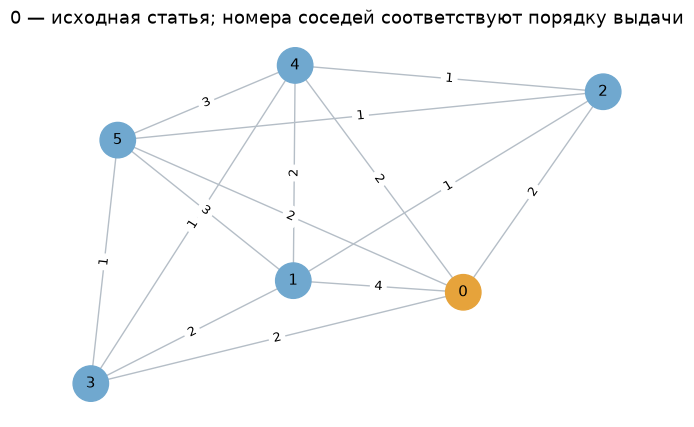

In [20]:
neighbors = recommend(paper_id, k=5)['ID'].tolist()
view = P.subgraph([paper_id] + neighbors)
positions = nx.spring_layout(view, seed=42, weight='similarity')
labels = {node: str(i) for i, node in enumerate([paper_id] + neighbors)}
plt.figure(figsize=(8, 5))
nx.draw_networkx(view, positions, labels=labels,
                 node_color=['#e6a33b' if node == paper_id else '#70a8cf' for node in view],
                 node_size=650, font_size=11, edge_color='#b5bec7')
nx.draw_networkx_edge_labels(view, positions, edge_labels=nx.get_edge_attributes(view, 'weight'), font_size=9)
plt.title('0 — исходная статья; номера соседей соответствуют порядку выдачи')
plt.axis('off')
plt.show()

### 5.1. Поиск по текстовому запросу
Запрос нормализуется так же, как теги. Добавляем в копию графа временную вершину запроса
и связываем её с публикациями, имеющими общий тег. Её соседей сортируем по среднему
TF-IDF-сходству тегов и текстов — так же, как при поиске по статье.
Исходный граф не изменяется. Если ни один тег не совпал, возвращаем пустой результат.


In [21]:
vocabulary = set().union(*tag_sets.values())


def search_publications(query, k=5):
    if not isinstance(k, int) or k < 0:
        raise ValueError('k должно быть неотрицательным целым числом')
    text = ' ' + normalize(query) + ' '
    matched = {term for term in vocabulary if ' ' + term + ' ' in text}
    if not matched or k == 0:
        return pd.DataFrame(columns=RESULT_COLUMNS)
    query_graph = P.copy()
    query_vector = vectorizer.transform([normalize(query)])
    query_tags = tag_vectorizer.transform([sorted(matched)])
    scores = (0.5 * (text_matrix @ query_vector.T) +
              0.5 * (tag_matrix @ query_tags.T)).toarray().ravel()
    query_node = '__query__'
    for pid, terms in tag_sets.items():
        common = matched & terms
        if common:
            query_graph.add_edge(query_node, pid, weight=len(common), similarity=float(scores[row_by_id[pid]]))
    neighbors = sorted(query_graph.neighbors(query_node),
                       key=lambda pid: (-query_graph[query_node][pid]['similarity'],
                                        -query_graph[query_node][pid]['weight'], pid))[:k]
    return pd.DataFrame([{
        'ID': pid, 'Название': titles[pid], 'Сходство': query_graph[query_node][pid]['similarity'],
        'Общих тегов': query_graph[query_node][pid]['weight'],
        'Общие теги': ', '.join(sorted(matched & tag_sets[pid])),
    } for pid in neighbors], columns=RESULT_COLUMNS)


query = 'federated learning'
display(search_publications(query).round(3))

,ID,Название,Сходство,Общих тегов,Общие теги
0,2305.17677,BFRT: Blockchained Federated Learning for Real-time Traffic Flow Prediction,0.314,2,"federated, federated learning"
1,2401.02723,Predicting Traffic Flow with Federated Learning and Graph Neural with Asynchronous Computations Network,0.310,2,"federated, federated learning"
2,2507.09805,Federated Learning with Graph-Based Aggregation for Traffic Forecasting,0.290,2,"federated, federated learning"
3,2407.12226,Individualized Federated Learning for Traffic Prediction with Error Driven Aggregation,0.285,2,"federated, federated learning"
4,2606.10499,MoE Enhanced Federated Learning for Spatiotemporal Prediction,0.272,2,"federated, federated learning"


## 6. Проверка поиска
Проверяем все пары статей: наличие ребра и его вес должны точно соответствовать общим тегам.
Отдельно проверяем сортировку, исключение самой исходной статьи, пустые запросы и неизвестные ID.

In [22]:
assert set(P) == set(papers['arxiv_id'])
assert nx.number_of_selfloops(P) == 0
for a, b in combinations(P, 2):
    common = tag_sets[a] & tag_sets[b]
    assert P.has_edge(a, b) == bool(common)
    if common:
        assert P[a][b]['weight'] == len(common)
        assert 0 < P[a][b]['similarity'] <= 1 + 1e-12
for pid in P:
    found = recommend(pid)
    assert pid not in set(found['ID']) and found['ID'].is_unique
    assert found['Сходство'].is_monotonic_decreasing
    assert set(found['ID']) <= set(P.neighbors(pid))
assert recommend(paper_id, 0).empty
assert search_publications('').empty and search_publications('zzzzzzzz').empty
try:
    recommend('unknown')
    raise AssertionError('Ожидалась ошибка неизвестного ID')
except ValueError:
    pass
assert np.allclose(text_similarity.diagonal(), 1.0)
assert np.allclose(text_similarity, text_similarity.T)
for pid, terms in tags.items():
    assert len(terms) == len(set(terms))
    assert len(terms) <= 12
    assert all(supported(term, pid) for term in terms)
print('Проверки пройдены:', len(P) * (len(P) - 1) // 2, 'пар статей')
original_edges = dict(((a, b), dict(data)) for a, b, data in P.edges(data=True))
query_results = search_publications('federated learning', k=5)
assert not query_results.empty and query_results['ID'].is_unique
assert query_results['Сходство'].is_monotonic_decreasing
assert set(query_results['ID']) <= set(P)
assert all('federated learning' in tag_sets[pid] for pid in query_results['ID'])
assert original_edges == dict(((a, b), dict(data)) for a, b, data in P.edges(data=True))
assert '__query__' not in P
assert search_publications('federated learning', k=0).empty
for invalid_k in [-1, 1.5]:
    for function, argument in [(recommend, paper_id), (search_publications, 'traffic')]:
        try:
            function(argument, invalid_k)
            raise AssertionError('Ожидалась ошибка параметра k')
        except ValueError:
            pass
print('Текстовый запрос, неизменность графа и валидация k: OK')


Проверки пройдены: 64980 пар статей
Текстовый запрос, неизменность графа и валидация k: OK


### 6.1. Оценка релевантности рекомендаций

**20 исходных публикаций · 5 рекомендаций для каждой · 100 оценённых пар**

Для каждой статьи получаем рекомендации и сопоставляем их с сохранённой разметкой
из `data/evaluation/search_relevance.json`. Метка **1** означает, что нужный метод
или задача подтверждены названием и аннотацией; иначе ставится **0**.
В файле сохранены темы запросов, критерии и пояснения к каждой оценке.

Разметка выполнена **AI-ассистентом по названиям и полным аннотациям**.
Метрики усредняются по всем 20 исходным публикациям, без разбиения на группы.
При расчёте языковая модель не вызывается.

Часть примеров ранее подбиралась с учётом выдачи; подробности формирования выборки
сохранены вместе с разметкой. Поэтому результат служит диагностикой поиска
и не заменяет независимую экспертную оценку на всём корпусе.

In [23]:
EVALUATION_PATH = ROOT / 'data/evaluation/search_relevance.json'
evaluation = json.loads(EVALUATION_PATH.read_text(encoding='utf-8'))
queries = evaluation['queries']
query_ids = [query['arxiv_id'] for query in queries]
assert evaluation['schema_version'] == 1
assert len(queries) == evaluation['query_count'] == 20
assert len(query_ids) == len(set(query_ids))
assert set(query_ids) <= set(P)
assert evaluation['recommendations_per_query'] == 5
for query in queries:
    labels = query['judgments']
    result_ids = [item['arxiv_id'] for item in labels]
    assert len(labels) == len(set(result_ids)) == 5
    assert set(result_ids) <= set(P) - {query['arxiv_id']}
    assert all(item['relevant'] in (0, 1) and item['reason'].strip() for item in labels)
print(f"Загружена разметка: {len(queries)} публикаций, "
      f"{sum(len(query['judgments']) for query in queries)} пар.")

Загружена разметка: 20 публикаций, 100 пар.


| Метрика | Что показывает |
| :--- | :--- |
| **Precision@3** | Средняя доля релевантных результатов на первых трёх местах. |
| **Precision@5** | Средняя доля релевантных результатов в первой пятёрке. |
| **MRR@5** | Среднее обратного ранга первого релевантного результата; 0, если его нет. |
| **Hit@5** | Доля исходных статей с хотя бы одним релевантным результатом в первой пятёрке. |

Все метрики лежат от 0 до 1: больше — лучше. Для Precision пустые места выдачи
считаются нерелевантными; каждая исходная статья имеет одинаковый вес в среднем.

In [24]:
metric_rows, audit_rows = [], []
METRIC_COLUMNS = ['Precision@3', 'Precision@5', 'MRR@5', 'Hit@5']
for query in queries:
    pid = query['arxiv_id']
    results = recommend(pid, k=5)
    assessed = {item['arxiv_id']: item for item in query['judgments']}
    unknown = set(results['ID']) - set(assessed)
    if unknown:
        raise ValueError(f'{pid}: нужна разметка новых результатов {sorted(unknown)}')
    relevance = [assessed[other]['relevant'] for other in results['ID']]
    first_hit = next((rank for rank, label in enumerate(relevance, 1) if label), None)
    metric_rows.append({'ID': pid, 'Тема': query['topic'],
                        'Precision@3': sum(relevance[:3]) / 3,
                        'Precision@5': sum(relevance) / 5,
                        'MRR@5': 1 / first_hit if first_hit else 0.0,
                        'Hit@5': float(first_hit is not None)})
    for rank, other in enumerate(results['ID'], 1):
        label = assessed[other]
        audit_rows.append({'Запрос': pid, 'Ранг': rank, 'Результат': other,
                           'Релевантен': label['relevant'], 'Причина': label['reason']})

metrics = pd.DataFrame(metric_rows).set_index('ID')
audit = pd.DataFrame(audit_rows)
evaluation_summary = metrics[METRIC_COLUMNS].mean().to_frame().T
evaluation_summary.index = ['Вся выборка']
display(evaluation_summary.style.format('{:.3f}')
        .set_caption(f'Качество поиска · {len(metrics)} исходных публикаций')
        .set_properties(**{'text-align': 'center', 'padding': '12px 18px',
                           'background-color': '#eef4fa', 'color': '#17324d'})
        .set_table_styles([
            {'selector': 'caption', 'props': [('text-align', 'left'),
                ('font-size', '16px'), ('font-weight', '600'), ('padding', '10px 0')]},
            {'selector': 'th', 'props': [('text-align', 'center'), ('padding', '10px 18px')]},
        ]))
print(f"Релевантных рекомендаций: {audit['Релевантен'].sum()} из {len(audit)}.")

,Precision@3,Precision@5,MRR@5,Hit@5
Вся выборка,0.667,0.600,0.867,1.000


Релевантных рекомендаций: 60 из 100.


### 6.2. Выводы по поиску

На всей выборке **Precision@3 = 0,667**, **Precision@5 = 0,600**,
**MRR@5 = 0,867**, **Hit@5 = 1,000**. Релевантны **60 из 100** рекомендаций.
В среднем в первой пятёрке находятся три подходящие статьи; для каждой исходной
публикации найден хотя бы один релевантный результат.

Высокий MRR@5 показывает, что первый подходящий результат обычно расположен близко
к началу выдачи. При этом Hit@5 = 1 не означает, что вся пятёрка качественная:
40% рекомендаций не соответствуют принятому критерию релевантности.

В выборке удачно представлены Transformer, прогноз скорости и оценка неопределённости.
Для MLP-моделей и прогноза при пропусках релевантна только одна из пяти рекомендаций;
в запросе о динамических графах первый подходящий результат находится на третьем месте.
Совпадение архитектурных терминов не всегда сохраняет нужную постановку задачи.